**Goal.** Build the horizontal mesh for the Great Britain ROI used in the Graph‑Weather pipeline.

**What this notebook does**
1. Defines the Region of Interest (ROI) and optional *ring/outer* bands.
2. Generates a spacing field (uniform or multi‑scale) on an ellipsoid.
3. Creates the mesh (lat‑lon grid or unstructured JIGSAW mesh).
4. Saves node coordinates and (optionally) base edges for the horizontal graph.

**Key parameters to set**
- `ROI_BOUNDS`: `[north, west, south, east]` (e.g. `[70, -30, 36, 2]` for GB + neighborhood).
- `RESOLUTION`: primary cell size in degrees for ROI (e.g. `0.25`).
- `RING/OUTER`: optional coarser spacing outside ROI (e.g. `0.5`, `1.0`).

**Expected outputs**
- NumPy `.npz` with node coordinates, e.g. `coord_lon[N]`, `coord_lat[N]`.
- If built here: base horizontal edges `edge_index_horiz_base[2, Eh]`.

**Tips**
- Keep the ellipsoid consistent with downstream processing.
- If you are using JIGSAW, verify the spacing field and minimum edge length to prevent orphaned triangles.

In [1]:
!apt-get update \
  && apt-get install -y build-essential cmake python3-dev

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,628 B]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:9 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,940 kB]
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,197 kB]
Hit:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRe

In [2]:
!apt-get -y install cmake g++ make

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
g++ is already the newest version (4:11.2.0-1ubuntu1).
g++ set to manually installed.
make is already the newest version (4.3-4.1build1).
make set to manually installed.
cmake is already the newest version (3.22.1-1ubuntu1.22.04.2).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.


In [ ]:
!git clone --depth 1 https://github.com/dengwirda/jigsaw-python.git
%cd jigsaw-python
!python3 build.py 
!pip install . 
%cd /content

Cloning into 'jigsaw-python'...
remote: Enumerating objects: 334, done.
remote: Counting objects: 100% (334/334), done.
remote: Compressing objects: 100% (307/307), done.
remote: Total 334 (delta 143), reused 71 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (334/334), 1.44 MiB | 8.17 MiB/s, done.
Resolving deltas: 100% (143/143), done.
/content/jigsaw-python
cmake config. for jigsaw...
['cmake', '..', '-DCMAKE_BUILD_TYPE=Release']
CMake Deprecation Warning at CMakeLists.txt:1 (cmake_minimum_required):
  Compatibility with CMake < 3.10 will be removed from a future version of
  CMake.

  Update the VERSION argument <min> value.  Or, use the <min>...<max> syntax
  to tell CMake that the project requires at least <min> but has been updated
  to work with policies introduced by <max> or earlier.


-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for 

In [ ]:
import os
os.environ["PATH"] = "/content/jigsaw-python/jigsawpy/external/jigsaw/build/bin:" + os.environ["PATH"]

In [ ]:
!which jigsaw

In [6]:
!pip install meshio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.2/166.2 kB 2.5 MB/s eta 0:00:00


In [41]:
!pip -q install cartopy shapely pyproj

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 86.2 MB/s eta 0:00:00


In [7]:
from __future__ import annotations


import math
from dataclasses import dataclass
from typing import Tuple, List
import tempfile


import numpy as np
import jigsawpy as jig
import meshio

In [8]:
@dataclass(frozen=True)
class Bounds:
    lon_min: float
    lon_max: float
    lat_min: float
    lat_max: float


    def expand(self, pad_lon: float, pad_lat: float) -> "Bounds":
        return Bounds(self.lon_min - pad_lon, self.lon_max + pad_lon,
                      self.lat_min - pad_lat, self.lat_max + pad_lat)


    def contains(self, lon: float, lat: float) -> bool:
        return (self.lon_min <= lon <= self.lon_max) and (self.lat_min <= lat <= self.lat_max)

In [9]:
# -------------------- spacing field (h(x)) -------------------- #

def build_latlon_hgrid(
    area: Bounds,
    roi: Bounds,
    roi_dx: float = 0.25,
    ring_dx: float = 0.50,
    outer_dx: float = 1.00,
    ring_pad: Tuple[float, float] = (6.0, 4.0),
    bg_dx: float = 5.0,
    base_step: float | None = None,
):
    """Construct an ELLIPSOID-GRID for JIGSAW with per-cell target spacings (degrees).
    Values are specified on a regular lat-lon grid covering the area.

    Args:
        base_step: resolution of the *h-grid*; default = min(roi_dx, ring_dx)/2 = 0.25/2.
    Returns:
        (xgrid, ygrid, H) where H[j,i] is spacing at (xgrid[i], ygrid[j]).
    """
    if base_step is None:
        base_step = min(roi_dx, ring_dx) * 0.5

    # grids are *node* coordinates expected by jigsaw: monotonically increasing
    xgrid = np.arange(area.lon_min, area.lon_max + 1e-9, base_step, dtype=float)
    ygrid = np.arange(area.lat_min, area.lat_max + 1e-9, base_step, dtype=float)

    NX, NY = len(xgrid), len(ygrid)
    H = np.full((NY, NX), bg_dx, dtype=float)

    ring = roi.expand(pad_lon=ring_pad[0], pad_lat=ring_pad[1])

    # vectorised assignment by masks
    X, Y = np.meshgrid(xgrid, ygrid)

    # ROI
    m_roi = (roi.lon_min <= X) & (X <= roi.lon_max) & (roi.lat_min <= Y) & (Y <= roi.lat_max)
    H[m_roi] = roi_dx

    # ring (outside ROI, within expanded bbox)
    m_ring = (ring.lon_min <= X) & (X <= ring.lon_max) & (ring.lat_min <= Y) & (Y <= ring.lat_max) & (~m_roi)
    H[m_ring] = ring_dx

    # outer (inside area, outside ring bbox)
    m_outer = (~m_roi) & (~m_ring)
    H[m_outer] = outer_dx

    return xgrid, ygrid, H

In [ ]:
# -------------------- JIGSAW driver -------------------- #
def run_jigsaw(
    xgrid_deg, ygrid_deg, H_deg,
    opt_iters: int = 8,
    opt_kern: str = "cvt+dqdx",
    qlim: float = 0.94,
    earth_radius_km: float = 6371.0,
    workdir: str | None = None,
    bin_path: str | None = None,
):
    import os, math, tempfile, shutil, subprocess, textwrap
    import numpy as np
    import jigsawpy as jig

    tmp = None
    if workdir is None:
        tmp = tempfile.TemporaryDirectory(prefix="jigsaw_work_")
        wd = tmp.name
    else:
        os.makedirs(workdir, exist_ok=True)
        wd = workdir

    geom_path = os.path.join(wd, "geom.msh")
    hfun_path = os.path.join(wd, "hfun.msh")
    mesh_path = os.path.join(wd, "mesh.msh")
    jcfg_path = os.path.join(wd, "jig.jig")
    log_path  = os.path.join(wd, "jigsaw.log")

    R = float(earth_radius_km)
    geom = jig.jigsaw_msh_t(); geom.mshID = "ELLIPSOID-MESH"
    geom.radii = np.array([R, R, R], dtype=np.float64)

    xgrid_deg = np.asarray(xgrid_deg, dtype=np.float64)
    ygrid_deg = np.asarray(ygrid_deg, dtype=np.float64)
    H_deg     = np.asarray(H_deg,     dtype=np.float64)
    H_km      = (math.pi / 180.0) * R * H_deg   # 1° ≈ R·π/180 км

    hfun = jig.jigsaw_msh_t(); hfun.mshID = "ELLIPSOID-GRID"
    hfun.radii = geom.radii.copy()
    hfun.xgrid = np.radians(xgrid_deg)
    hfun.ygrid = np.radians(ygrid_deg)
    hfun.value = H_km

    jig.savemsh(geom_path, geom)
    jig.savemsh(hfun_path, hfun)

    jcfg_txt = textwrap.dedent(f"""
        GEOM_FILE = {geom_path}
        HFUN_FILE = {hfun_path}
        MESH_FILE = {mesh_path}
        MESH_DIMS = 2

        HFUN_SCAL = ABSOLUTE
        HFUN_HMIN = {float(np.nanmin(H_km))}
        HFUN_HMAX = {float(np.nanmax(H_km))}

        OPTM_KERN = "{opt_kern}"
        OPTM_ITER = {int(opt_iters)}
        OPTM_QLIM = {float(qlim)}
        OPTM_ZIP_ = true
        OPTM_DIV_ = true
        OPTM_TRIA = true

        VERBOSITY = 2
        LOG_FILE  = {log_path}
    """).strip() + "\n"
    with open(jcfg_path, "w") as f:
        f.write(jcfg_txt)

    cand = []
    if bin_path: cand.append(bin_path)  
    cand.append("/content/jigsaw-python/jigsawpy/external/jigsaw/build/bin/jigsaw")
    cand.append("/content/jigsaw-python/external/jigsaw/build/bin/jigsaw")
    cand.append(os.path.join(os.path.dirname(jig.__file__), "_bin", "jigsaw"))
    found = shutil.which("jigsaw")
    if found: cand.append(found)

    exe = next((p for p in cand if p and os.path.isfile(p) and os.access(p, os.X_OK)), None)
    if exe is None:
        raise RuntimeError(
            "NoJIGSAW executable. Передай bin_path=... або збудуй core.\n"
        )

    proc = subprocess.run([exe, jcfg_path], capture_output=True, text=True)
    if proc.returncode != 0:
        log_tail = ""
        if os.path.isfile(log_path):
            try:
                with open(log_path, "r") as f: log_tail = "".join(f.readlines()[-120:])
            except Exception: pass
        raise RuntimeError(
            f"JIGSAW failed (code={proc.returncode}).\n"
            f"STDOUT:\n{proc.stdout}\n\nSTDERR:\n{proc.stderr}\n\n"
            f"LOG TAIL ({log_path}):\n{log_tail}"
        )

    try:
        mesh = jig.jigsaw_msh_t()
        jig.loadmsh(mesh_path, mesh) 
    except TypeError:
        mesh = jig.loadmsh(mesh_path) 

    if tmp is not None:
        try: tmp.cleanup()
        except Exception: pass

    return mesh

In [11]:
# -------------------- utilities -------------------- #

def xyz_to_lonlat(XYZ: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    x, y, z = XYZ[:, 0], XYZ[:, 1], XYZ[:, 2]
    lon = np.degrees(np.arctan2(y, x))
    r = np.sqrt(x * x + y * y + z * z)
    lat = np.degrees(np.arcsin(np.clip(z / r, -1.0, 1.0)))
    # wrap lon to [-180,180]
    lon = (lon + 180.0) % 360.0 - 180.0
    return lon, lat


def crop_to_bbox(verts_ll: np.ndarray, tris: np.ndarray, area: Bounds) -> tuple[np.ndarray, np.ndarray]:
    # keep triangles whose centroid lies in bbox
    v0 = verts_ll[tris[:, 0], :]
    v1 = verts_ll[tris[:, 1], :]
    v2 = verts_ll[tris[:, 2], :]
    C = (v0 + v1 + v2) / 3.0
    m = (area.lon_min <= C[:, 0]) & (C[:, 0] <= area.lon_max) & (area.lat_min <= C[:, 1]) & (C[:, 1] <= area.lat_max)
    tris_sel = tris[m]
    # reindex vertices to a compact range
    used = np.unique(tris_sel.reshape(-1))
    remap = -np.ones(len(verts_ll), dtype=int)
    remap[used] = np.arange(len(used), dtype=int)
    tris_new = remap[tris_sel]
    verts_new = verts_ll[used]
    return verts_new, tris_new


def project_equirect(verts_ll: np.ndarray, center_hint: tuple[float, float]) -> np.ndarray:
    lon0, lat0 = center_hint
    c = math.cos(math.radians(lat0))
    x = (verts_ll[:, 0] - lon0) * c
    y = (verts_ll[:, 1] - lat0)
    return np.c_[x, y, np.zeros_like(x)]


def save_npz(path: str, verts_ll: np.ndarray, tris: np.ndarray) -> None:
    np.savez_compressed(path, verts_ll=verts_ll, tris=tris)


def save_vtk(path: str, verts_ll: np.ndarray, tris: np.ndarray, center_hint: tuple[float, float]) -> None:
    if not _HAVE_MESHIO:
        raise RuntimeError("meshio is required for VTK export. pip install meshio")
    pts_xyz = project_equirect(verts_ll, center_hint)
    cells = [("triangle", tris.astype(np.int64))]
    mesh = meshio.Mesh(points=pts_xyz, cells=cells, point_data={"lon": verts_ll[:, 0], "lat": verts_ll[:, 1]})
    meshio.write(path, mesh)

In [13]:
area = Bounds(lon_min=-50.0, lon_max=20.0, lat_min=30.0, lat_max=75.0)
roi  = Bounds(lon_min=-11.0, lon_max= 2.0, lat_min=49.0, lat_max=59.0)

# spacing spec
ROI_DX   = 0.25
RING_DX  = 0.50
OUT_DX   = 1.00
RING_PAD = (6.0, 4.0)   # degrees around ROI for the 0.5° belt

In [14]:
# build h(x) on a helper lat-lon grid
xgrid, ygrid, H = build_latlon_hgrid(area, roi, ROI_DX, RING_DX, OUT_DX, ring_pad=RING_PAD, bg_dx=5.0)

In [27]:
# run JIGSAW on an Earth ellipsoid (unit sphere scaled by R)

mesh = run_jigsaw(
    xgrid, ygrid, H,
    opt_iters=8, opt_kern="cvt+dqdx", qlim=0.94,
    bin_path="/content/jigsaw-python/external/jigsaw/bin/jigsaw",
)

In [29]:
# unpack nodes/triangles and convert to lon/lat
XYZ = np.asarray(mesh.point["coord"], dtype=float)
TRIA = np.asarray(mesh.tria3["index"], dtype=np.int64) if hasattr(mesh, "tria3") else None
if TRIA is None or TRIA.size == 0:
    raise RuntimeError("No triangles returned by JIGSAW; check installation and inputs.")

lon, lat = xyz_to_lonlat(XYZ)
VLL = np.c_[lon, lat]

# crop to area bbox
V_crop, T_crop = crop_to_bbox(VLL, TRIA, area)

# save
save_npz("./multiscale_jigsaw_ll.npz", V_crop, T_crop)
print(f"Saved NPZ: multiscale_jigsaw_ll.npz | Nverts={len(V_crop)} Ntris={len(T_crop)}")

# optional VTK (projected X-Y for plotting)
try:
    center = ((area.lon_min + area.lon_max) * 0.5, (area.lat_min + area.lat_max) * 0.5)
    save_vtk("./multiscale_jigsaw_xy.vtk", V_crop, T_crop, center_hint=center)
    print("Saved VTK: multiscale_jigsaw_xy.vtk")
except Exception as e:
    print(f"[VTK export skipped] {e}")

# quick sanity check
print(f"lon: {V_crop[:,0].min():.2f}..{V_crop[:,0].max():.2f}  |  lat: {V_crop[:,1].min():.2f}..{V_crop[:,1].max():.2f}")

Saved NPZ: multiscale_jigsaw_ll.npz | Nverts=4227 Ntris=8240
[VTK export skipped] name '_HAVE_MESHIO' is not defined
lon: -51.13..21.26  |  lat: 29.42..75.51


In [35]:
import os, numpy as np, pathlib
print("CWD:", os.getcwd())

npz_path = "/content/multiscale_jigsaw_ll.npz"  # змінюй якщо треба
dat = np.load(npz_path)
verts_ll = dat["verts_ll"]   # (N,2) [lon,lat]
tris     = dat["tris"]       # (M,3) indices
print("Loaded:", npz_path, "| Nverts=", len(verts_ll), "Ntris=", len(tris))

CWD: /
Loaded: /content/multiscale_jigsaw_ll.npz | Nverts= 4227 Ntris= 8240


In [ ]:
# === Mesh quality metrics on the sphere (km) + relative edge-length h_r ===
import numpy as np, pandas as pd
from math import radians, sin, cos, atan2, sqrt
R_KM = 6371.0

def haversine_km(lon1,lat1, lon2,lat2, R=R_KM):
    lon1,lat1,lon2,lat2 = map(np.radians, (lon1,lat1,lon2,lat2))
    dlon, dlat = lon2-lon1, lat2-lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2*np.arctan2(np.sqrt(a), np.sqrt(np.maximum(1e-16, 1-a)))
    return R*c

def mesh_quality(verts_ll, tris):
    i,j,k = tris[:,0], tris[:,1], tris[:,2]
    lon, lat = verts_ll[:,0], verts_ll[:,1]
    a = haversine_km(lon[j],lat[j], lon[k],lat[k])  # opposite i
    b = haversine_km(lon[i],lat[i], lon[k],lat[k])  # opposite j
    c = haversine_km(lon[i],lat[i], lon[j],lat[j])  # opposite k
    s = 0.5*(a+b+c)
    area = np.sqrt(np.maximum(0.0, s*(s-a)*(s-b)*(s-c)))
    # angles (deg) via cosine rule
    clamp = lambda x: np.clip(x, -1.0, 1.0)
    A = np.degrees(np.arccos(clamp((b*b + c*c - a*a)/(2*b*c))))
    B = np.degrees(np.arccos(clamp((a*a + c*c - b*b)/(2*a*c))))
    C = np.degrees(np.arccos(clamp((a*a + b*b - c*c)/(2*a*b))))
    min_ang = np.minimum(np.minimum(A,B), C)
    max_ang = np.maximum(np.maximum(A,B), C)
    Q_area_len = (4.0*np.sqrt(3.0)*area) / np.maximum(1e-12, (a*a+b*b+c*c))
    Rcirc = (a*b*c) / np.maximum(1e-12, 4.0*area)
    rmin  = np.minimum(np.minimum(a,b), c)
    rho   = Rcirc / np.maximum(1e-12, rmin)
    df = pd.DataFrame({
        "area_km2": area,
        "min_angle_deg": min_ang,
        "max_angle_deg": max_ang,
        "Q_area_len": Q_area_len,
        "rho_radius_edge": rho,
        "edge_min_km": rmin,
        "edge_mean_km": (a+b+c)/3.0
    })
    # vertex degree
    deg = np.zeros(len(verts_ll), dtype=np.int32)
    for t in tris: deg[t] += 1
    return df, deg

# relative edge-length h_r vs target spacing H (deg→km) at triangle centroid
def bilinear_interp(xg, yg, Z, xq, yq):
    # xg, yg are 1D increasing; Z shape (len(yg), len(xg)); queries xq,yq scalars or arrays
    xg = np.asarray(xg); yg = np.asarray(yg); Z = np.asarray(Z)
    xq = np.asarray(xq); yq = np.asarray(yq)
    ix = np.clip(np.searchsorted(xg, xq) - 1, 0, len(xg)-2)
    iy = np.clip(np.searchsorted(yg, yq) - 1, 0, len(yg)-2)
    x0, x1 = xg[ix], xg[ix+1]
    y0, y1 = yg[iy], yg[iy+1]
    tx = np.clip((xq - x0) / np.maximum(1e-12, x1 - x0), 0, 1)
    ty = np.clip((yq - y0) / np.maximum(1e-12, y1 - y0), 0, 1)
    Z00 = Z[iy, ix]; Z10 = Z[iy, ix+1]; Z01 = Z[iy+1, ix]; Z11 = Z[iy+1, ix+1]
    return (1-tx)*(1-ty)*Z00 + tx*(1-ty)*Z10 + (1-tx)*ty*Z01 + tx*ty*Z11

try:
    xgrid, ygrid, Hdeg = xgrid, ygrid, H  # з попередньої сесії
except NameError:
    # rebuild quick H-field in degrees (ROI 0.25°, ring 0.5°, outer 1.0°)
    area = (-50.0, 20.0, 30.0, 75.0)
    roi  = (-11.0, 2.0, 49.0, 59.0)
    base_step = 0.125
    xgrid = np.arange(area[0], area[1]+1e-9, base_step)
    ygrid = np.arange(area[2], area[3]+1e-9, base_step)
    X,Y = np.meshgrid(xgrid, ygrid)
    Hdeg = np.full_like(X, 1.0)
    in_roi  = (X>=roi[0])&(X<=roi[1])&(Y>=roi[2])&(Y<=roi[3])
    ring = (X>=roi[0]-6)&(X<=roi[1]+6)&(Y>=roi[2]-4)&(Y<=roi[3]+4)&(~in_roi)
    Hdeg[in_roi]=0.25; Hdeg[ring]=0.5; Hdeg[~(in_roi|ring)]=1.0

df, degree = mesh_quality(verts_ll, tris)

# h_r at triangle centroids:
cent = (verts_ll[tris[:,0]] + verts_ll[tris[:,1]] + verts_ll[tris[:,2]])/3.0
Hdeg_cent = bilinear_interp(xgrid, ygrid, Hdeg, cent[:,0], cent[:,1])
Hkm_cent  = Hdeg_cent * (np.pi/180.0) * R_KM
df["h_r"] = df["edge_mean_km"].values / np.maximum(1e-6, Hkm_cent)

# summary
print(df[["min_angle_deg","max_angle_deg","Q_area_len","rho_radius_edge","edge_mean_km","h_r"]]
      .describe(percentiles=[.05,.25,.5,.75,.95]))
print("Vertex degree: mean=%.2f  min=%d  max=%d" % (degree.mean(), degree.min(), degree.max()))

       min_angle_deg  max_angle_deg   Q_area_len  rho_radius_edge  \
count    8240.000000    8240.000000  8240.000000      8240.000000   
mean       55.446537      65.090355     0.988252         0.610130   
std         3.943481       4.776613     0.017152         0.032565   
min        39.266587      60.000000     0.879114         0.577350   
5%         47.452691      60.312091     0.948115         0.579297   
25%        53.204445      61.441453     0.984986         0.585767   
50%        56.698849      63.429901     0.996487         0.598232   
75%        58.603424      67.388342     0.999374         0.624393   
95%        59.668237      75.664223     0.999965         0.678685   
max        60.000000      87.550925     1.000000         0.789977   

       edge_mean_km          h_r  
count   8240.000000  8240.000000  
mean      71.637977     1.006137  
std       37.401029     0.066030  
min       24.941882     0.630959  
5%        27.402984     0.938484  
25%       28.270686     0.9926

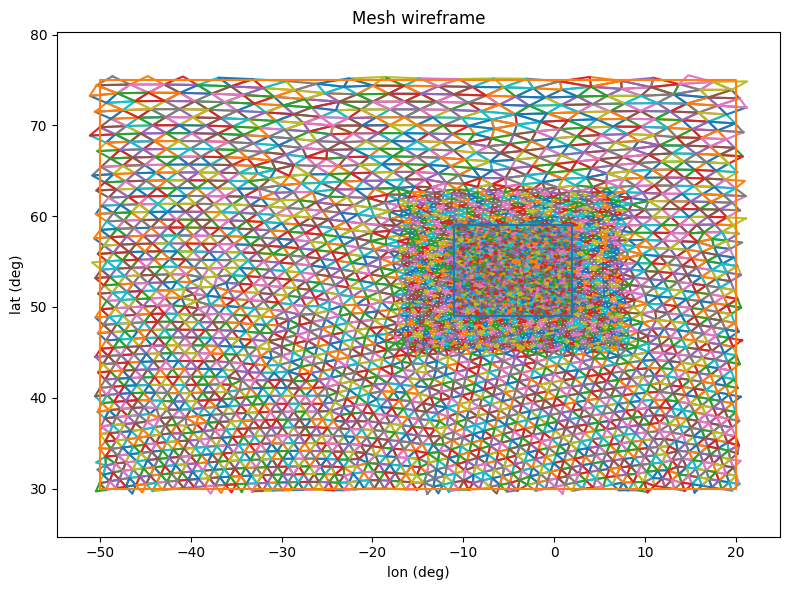

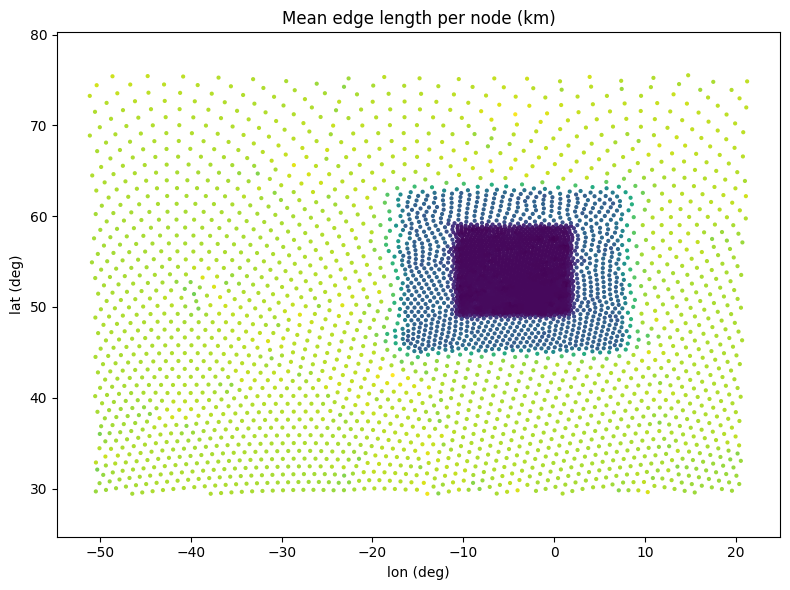

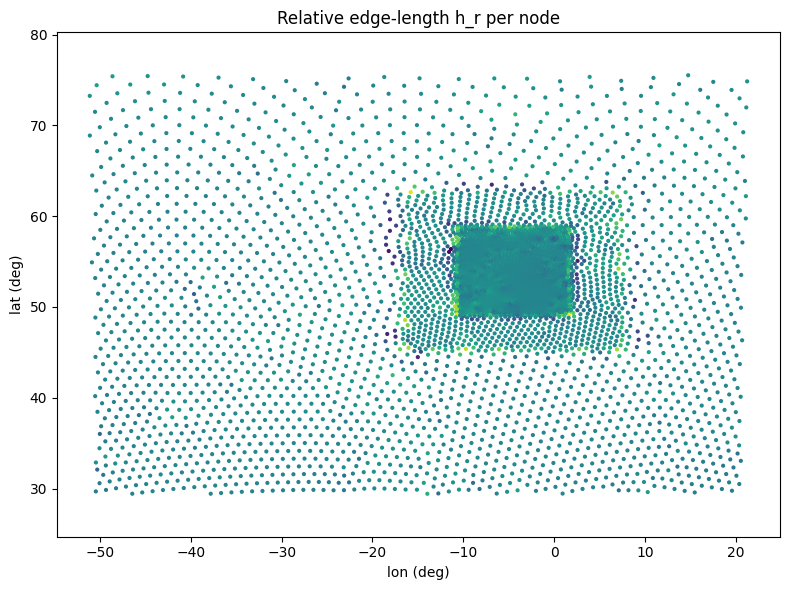

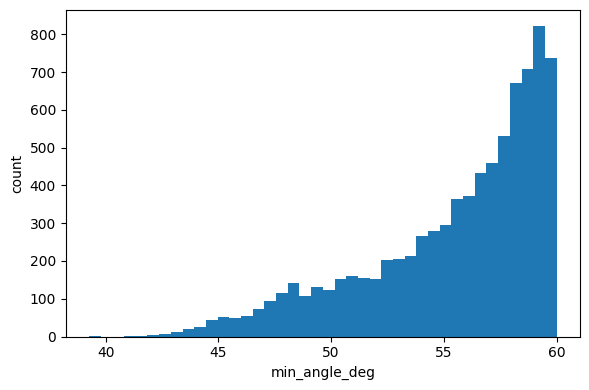

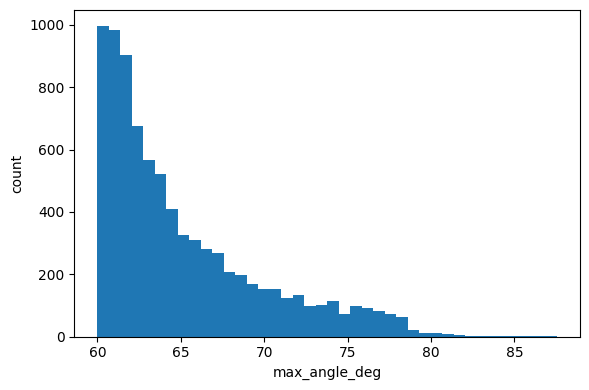

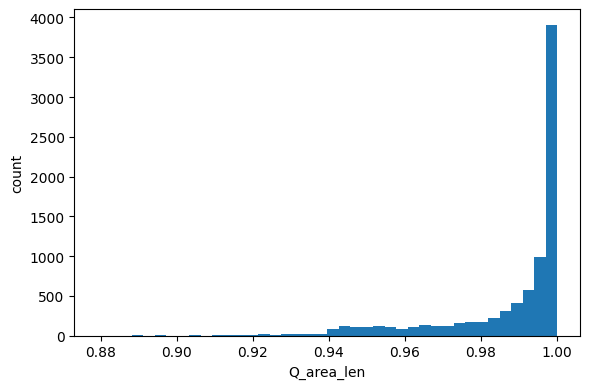

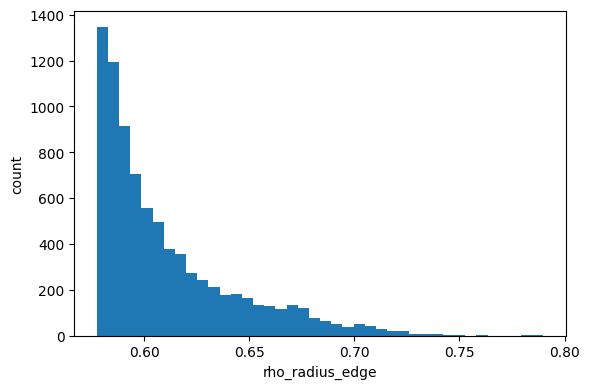

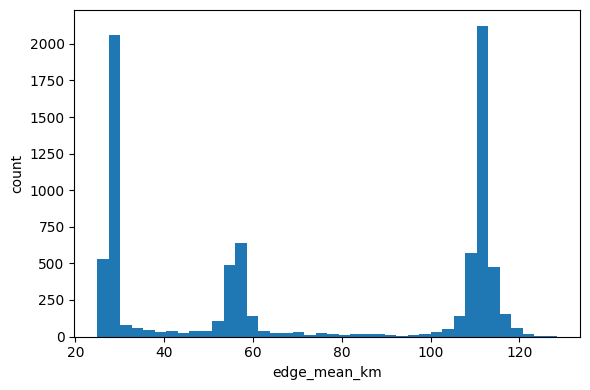

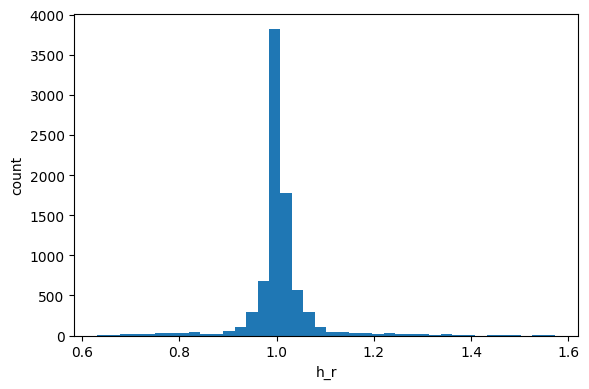

In [37]:
import matplotlib.pyplot as plt
from dataclasses import dataclass

@dataclass(frozen=True)
class Bounds:
    lon_min: float; lon_max: float; lat_min: float; lat_max: float

area = Bounds(-50, 20, 30, 75)
roi  = Bounds(-11, 2, 49, 59)

def plot_mesh_wire(verts_ll, tris, roi=None, area=None, every=1):
    V, T = verts_ll, tris[::every]
    plt.figure(figsize=(8,6))
    for tri in T:
        cyc = np.r_[tri, tri[0]]
        plt.plot(V[cyc,0], V[cyc,1])
    if roi:
        rx = [roi.lon_min, roi.lon_max, roi.lon_max, roi.lon_min, roi.lon_min]
        ry = [roi.lat_min, roi.lat_min, roi.lat_max, roi.lat_max, roi.lat_min]
        plt.plot(rx, ry)
    if area:
        ax = [area.lon_min, area.lon_max, area.lon_max, area.lon_min, area.lon_min]
        ay = [area.lat_min, area.lat_min, area.lat_max, area.lat_max, area.lat_min]
        plt.plot(ax, ay)
    plt.xlabel("lon (deg)"); plt.ylabel("lat (deg)"); plt.title("Mesh wireframe")
    plt.axis("equal"); plt.tight_layout(); plt.show()

def plot_nodes_by(value_per_vert, title="Node value"):
    plt.figure(figsize=(8,6))
    plt.scatter(verts_ll[:,0], verts_ll[:,1], s=4, c=value_per_vert)
    plt.xlabel("lon (deg)"); plt.ylabel("lat (deg)"); plt.title(title)
    plt.axis("equal"); plt.tight_layout(); plt.show()

def per_vertex_from_tri(tris, tri_values, nverts):
    acc = np.zeros(nverts); cnt = np.zeros(nverts)
    for t, tri in enumerate(tris):
        acc[tri] += tri_values[t]
        cnt[tri] += 1
    return np.divide(acc, np.maximum(1, cnt))

def plot_quality_hist(df):
    for col in ["min_angle_deg","max_angle_deg","Q_area_len","rho_radius_edge","edge_mean_km","h_r"]:
        plt.figure(figsize=(6,4))
        plt.hist(df[col].values, bins=40)
        plt.xlabel(col); plt.ylabel("count"); plt.tight_layout(); plt.show()

# wireframe
plot_mesh_wire(verts_ll, tris, roi=roi, area=area, every=1)

# colour by local scale proxy (mean edge length)
v_scale = per_vertex_from_tri(tris, df["edge_mean_km"].values, len(verts_ll))
plot_nodes_by(v_scale, title="Mean edge length per node (km)")

# colour by h_r (relative edge length)
v_hr = per_vertex_from_tri(tris, df["h_r"].values, len(verts_ll))
plot_nodes_by(v_hr, title="Relative edge-length h_r per node")

# histograms
plot_quality_hist(df)

In [42]:
# --- 1) Load mesh (verts_ll, tris) from NPZ ---
import os, numpy as np, pathlib

# Try both common paths
candidates = ["/content/multiscale_jigsaw_ll.npz", "/multiscale_jigsaw_ll.npz"]
npz_path = next((p for p in candidates if os.path.exists(p)), None)
if npz_path is None:
    raise FileNotFoundError("Не можу знайти multiscale_jigsaw_ll.npz ані в /content, ані в /.")
dat = np.load(npz_path)
verts_ll = dat["verts_ll"]   # (N,2) [lon, lat]
tris     = dat["tris"]       # (M,3) int
print(f"Loaded: {npz_path} | Nverts={len(verts_ll)} Ntris={len(tris)}")

Loaded: /content/multiscale_jigsaw_ll.npz | Nverts=4227 Ntris=8240


In [ ]:
# --- 2) Helpers: bounds, unique edges -> segments for plotting ---
from dataclasses import dataclass
import numpy as np

@dataclass(frozen=True)
class Bounds:
    lon_min: float; lon_max: float; lat_min: float; lat_max: float

area = Bounds(-50, 20, 30, 75)
roi  = Bounds(-11,  2, 49, 59)

def mesh_edges_as_segments(verts_ll: np.ndarray, tris: np.ndarray) -> np.ndarray:
    """
    Повертає масив сегментів (K, 2, 2) у lon/lat для унікальних ребер.
    """
    e = np.vstack([tris[:,[0,1]], tris[:,[1,2]], tris[:,[2,0]]])
    e = np.sort(e, axis=1)
    e = np.unique(e, axis=0)
    segs = np.stack([verts_ll[e[:,0]], verts_ll[e[:,1]]], axis=1)  # (K, 2, 2)
    return segs

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


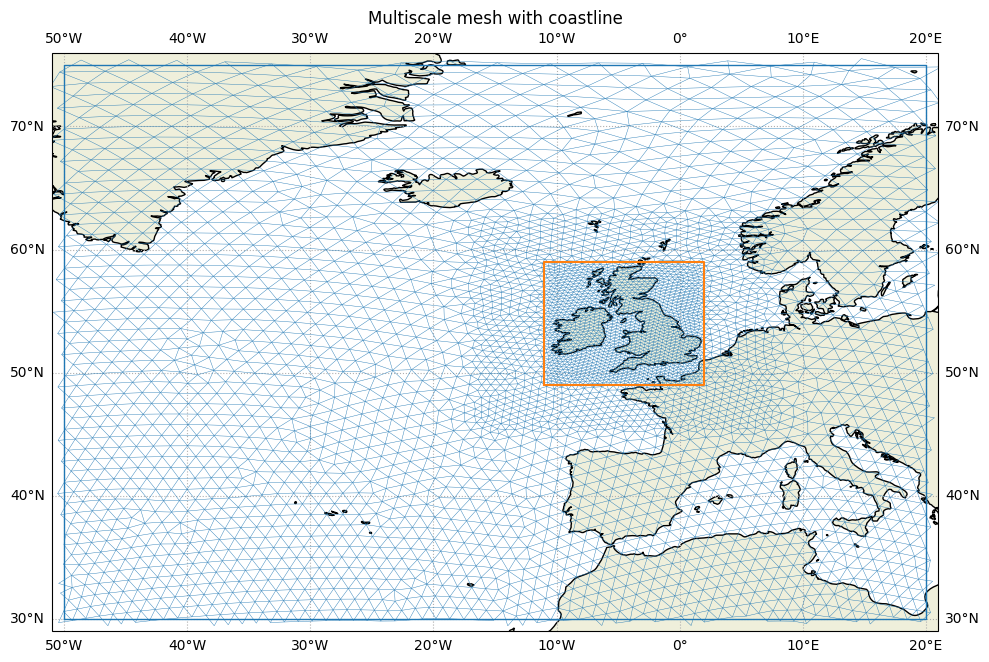

Saved figure to: /content/mesh_with_coastline.png


In [ ]:
# --- 3) Plot with Cartopy coastlines + area/ROI boxes + mesh edges ---
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.collections import LineCollection

def plot_mesh_with_coastline(verts_ll, tris, area: Bounds, roi: Bounds,
                             every_edge: int = 1,
                             coastline_res: str = "50m",
                             out_png: str = "/content/mesh_with_coastline.png"):

    # побудова сегментів ребер
    segs = mesh_edges_as_segments(verts_ll, tris)
    if every_edge > 1:
        segs = segs[::every_edge]

    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(10, 8))
    ax = plt.axes(projection=proj)

    # coastlines & land
    ax.set_extent([area.lon_min-1, area.lon_max+1, area.lat_min-1, area.lat_max+1], crs=proj)
    ax.add_feature(cfeature.LAND, zorder=0)
    ax.add_feature(cfeature.COASTLINE.with_scale(coastline_res), zorder=1)
    ax.gridlines(draw_labels=True, linestyle=":")

    # mesh edges as LineCollection
    lc = LineCollection(segs, linewidths=0.3, zorder=2)
    lc.set_transform(proj)  # важливо: lon/lat coords
    ax.add_collection(lc)

    # plot ROI & AREA boxes
    def box(b: Bounds):
        xs = [b.lon_min, b.lon_max, b.lon_max, b.lon_min, b.lon_min]
        ys = [b.lat_min, b.lat_min, b.lat_max, b.lat_max, b.lat_min]
        return np.array(xs), np.array(ys)
    xR, yR = box(roi)
    xA, yA = box(area)
    ax.plot(xA, yA, transform=proj, linewidth=1.0, zorder=3)
    ax.plot(xR, yR, transform=proj, linewidth=1.5, zorder=4)

    ax.set_title("Multiscale mesh with coastline")
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.show()
    print("Saved figure to:", out_png)

plot_mesh_with_coastline(verts_ll, tris, area, roi, every_edge=1, coastline_res="50m",
                         out_png="/content/mesh_with_coastline.png")